# Séance 2 — Régression linéaire : du modèle statistique à l'évaluation

## Fil rouge : Diabetes

Nous allons maintenant construire notre premier modèle.

Objectifs :
- comprendre le modèle linéaire ;
- comprendre ce que sont les paramètres ;
- comprendre la fonction de perte ;
- ajuster une régression avec `scikit-learn` ;
- calculer MSE, RMSE, MAE et R² ;
- analyser les coefficients avec `statsmodels` ;
- étudier leur significativité.

## 1. Le modèle linéaire

Avec une variable :

$
Y = \beta_0 + \beta_1X + \varepsilon
$

Avec plusieurs variables :

$
Y =
\beta_0+
\beta_1X_1+
\cdots+
\beta_pX_p+
\varepsilon
$

Les $\beta_j$ sont les **paramètres** du modèle.

Le modèle produit une prédiction :

$
\hat Y =
\beta_0+
\beta_1X_1+
\cdots+
\beta_pX_p
$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(Xtr.shape)
print(Xte.shape)

(353, 10)
(89, 10)


## 2. Pourquoi séparer train et test ?

Le modèle doit apprendre sur certaines observations puis être évalué sur des observations qu'il n'a pas utilisées pour apprendre.

- `Xtr`, `ytr` : apprentissage ;
- `Xte`, `yte` : évaluation finale.

C'est une première façon d'étudier la **généralisation**.

## 3. Ajuster le modèle

Avec `scikit-learn` :

```python
modele.fit(Xtr, ytr)
```

fait apprendre les paramètres du modèle à partir des données.

In [3]:
modele = LinearRegression()

modele.fit(Xtr, ytr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 37.9 ,-241.96, 542.43,..., 275.32, 736.2 , 48.67]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1.78,1.08,1. ,...,0.59,0.25,0.09]"


In [4]:
print("Intercept :", modele.intercept_)

for nom, coef in zip(diabetes.feature_names, modele.coef_):
    print(f"{nom:>5} : {coef:8.3f}")

Intercept : 151.34560453985995
  age :   37.904
  sex : -241.964
  bmi :  542.429
   bp :  347.704
   s1 : -931.489
   s2 :  518.062
   s3 :  163.420
   s4 :  275.318
   s5 :  736.199
   s6 :   48.671


### Que fait réellement `fit()` ?

Le modèle cherche les coefficients qui rendent les prédictions aussi proches que possible des observations d'entraînement.

Pour la régression linéaire, on utilise classiquement la somme des carrés des erreurs :

$
\sum_{i=1}^n (y_i-\hat y_i)^2
$

C'est l'origine des **moindre carrés**.

Pour le modèle

$$ y=X\beta+\varepsilon, $$

l'estimateur des moindres carrés ordinaires est

$$ \hat\beta_{\mathrm{OLS}} =(X^TX)^{-1}X^Ty $$

lorsque $X^TX$ est inversible avec $X=[1 X_1 \ldots X_p]$.

`LinearRegression` de scikit-learn cherche bien l'estimateur OLS, mais il ne calcule pas naïvement $(X^TX)^{-1}X^Ty$. Il utilise une méthode de résolution numérique des moindres carrés, basée notamment sur la décomposition en valeurs singulières (SVD) plutôt que de former explicitement l'inverse de $X^TX$.

C'est important numériquement, car calculer explicitement

$$ (X^TX)^{-1} $$

peut être instable lorsque les variables explicatives sont fortement corrélées ou lorsque $X$ est mal conditionnée.

## 4. La fonction de perte

Une façon de mesurer l'erreur moyenne est :

$
MSE =
\frac{1}{n}
\sum_{i=1}^n
(y_i-\hat y_i)^2
$

Pourquoi mettre au carré ?

- les erreurs positives et négatives ne s'annulent pas ;
- les grosses erreurs sont davantage pénalisées.

In [5]:
ytr_pred = modele.predict(Xtr)
yte_pred = modele.predict(Xte)

mse_train = mean_squared_error(ytr, ytr_pred)
mse_test = mean_squared_error(yte, yte_pred)

print("MSE train :", mse_train)
print("MSE test  :", mse_test)

MSE train : 2868.549702835577
MSE test  : 2900.1936284934804


## 5. Les critères d'évaluation

### MSE

$
MSE = \frac1n\sum(y_i-\hat y_i)^2
$

Plus petit = meilleur.

### RMSE

$
RMSE = \sqrt{MSE}
$

Il est exprimé dans l'unité de la variable cible.

### MAE

$
MAE = \frac1n\sum|y_i-\hat y_i|
$

### R²

$
R^2 =
1 -
\frac{\sum(y_i-\hat y_i)^2}
{\sum(y_i-\bar y)^2}
$

Le dénominateur correspond à l'erreur obtenue si l'on prédit toujours la moyenne de `y`.

In [5]:
rmse_train = np.sqrt(mean_squared_error(ytr, ytr_pred))
rmse_test = np.sqrt(mean_squared_error(yte, yte_pred))

mae_train = mean_absolute_error(ytr, ytr_pred)
mae_test = mean_absolute_error(yte, yte_pred)

r2_train = r2_score(ytr, ytr_pred)
r2_test = r2_score(yte, yte_pred)

print(f"Train : MSE={mse_train:.2f}, RMSE={rmse_train:.2f}, MAE={mae_train:.2f}, R²={r2_train:.3f}")
print(f"Test  : MSE={mse_test:.2f}, RMSE={rmse_test:.2f}, MAE={mae_test:.2f}, R²={r2_test:.3f}")

Train : MSE=2868.55, RMSE=53.56, MAE=43.48, R²=0.528
Test  : MSE=2900.19, RMSE=53.85, MAE=42.79, R²=0.453


### Question d'interprétation

Comparez les performances train et test.

- Les scores sont-ils proches ?
- Que peut-on dire sur le surapprentissage dans ce cas ?
- Pourquoi le R² du test peut-il être plus faible que celui du train ?

## 6. Visualiser prédictions et observations

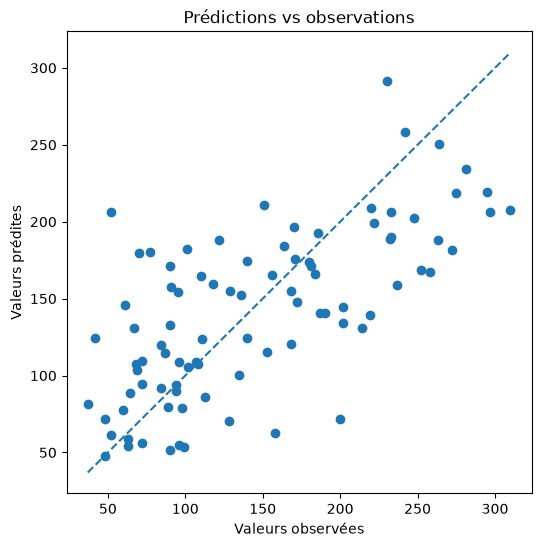

In [6]:
plt.figure(figsize=(6, 6))

plt.scatter(yte, yte_pred)

minimum = min(yte.min(), yte_pred.min())
maximum = max(yte.max(), yte_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Valeurs observées")
plt.ylabel("Valeurs prédites")
plt.title("Prédictions vs observations")
plt.show()

Si le modèle prédisait parfaitement, tous les points seraient sur la droite :

$
\hat y = y
$

Plus les points s'en éloignent, plus les erreurs sont importantes.

## 7. Une approche statistique avec `statsmodels`

`scikit-learn` est particulièrement pratique pour construire des modèles prédictifs.

`statsmodels` fournit davantage d'outils pour l'inférence statistique :
- erreurs standards ;
- statistiques de test ;
- p-values ;
- intervalles de confiance.

In [6]:
import statsmodels.api as sm

Xtr_df = pd.DataFrame(
    Xtr,
    columns=diabetes.feature_names
)

Xtr_sm = sm.add_constant(Xtr_df)

modele_sm = sm.OLS(ytr, Xtr_sm).fit()

print(modele_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     38.25
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           5.41e-50
Time:                        11:41:25   Log-Likelihood:                -1906.1
No. Observations:                 353   AIC:                             3834.
Df Residuals:                     342   BIC:                             3877.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        151.3456      2.902     52.155      0.0

En théorie, on devrait avoir

$$ \hat\beta=(X^TX)^{-1}X^Ty $$

Si on a  le modèle 

$$ y=X\beta+\varepsilon $$

avec l'hypothèse :

$$ \varepsilon\sim\mathcal N(0,\sigma^2I). $$

Alors l'estimateur $\hat\beta$ est lui-même une variable aléatoire :

$$ \hat\beta\sim \mathcal N\left( \beta,\; \sigma^2(X^TX)^{-1} \right). $$

$\sigma^2(X^TX)^{-1}$ est la matrice de variance-covariance des coefficients.

La variance de chaque coefficient \(\hat\beta_j\) est donnée par la diagonale de cette matrice :

$$ \operatorname{Var}(\hat\beta_j) = \sigma^2 \left[(X^TX)^{-1}\right]_{jj}. $$

Donc son erreur standard est :

$$ \boxed{ SE(\hat\beta_j) = \sqrt{ \sigma^2 \left[(X^TX)^{-1}\right]_{jj} } } $$

Mais on ne connaît pas $\sigma^2$, la variance réelle des erreurs.

On l'estime donc avec les résidus.

Après avoir ajusté le modèle, on calcule les résidus :

$$ e_i=y_i-\hat y_i. $$

La somme des carrés des résidus est :

$$ RSS=\sum_{i=1}^n(y_i-\hat y_i)^2. $$

On estime alors :

$$ \hat\sigma^2 = \frac{RSS}{n-(p+1)} $$

où :

$n$ = nombre d'observations ;
$p$ = nombre de paramètres estimés sans l'intercept.

On obtient donc finalement :

$$ \boxed{ SE(\hat\beta_j) = \sqrt{ \hat\sigma^2 \left[(X^TX)^{-1}\right]_{jj} } } $$

Le SE dépend donc de deux choses :

$$ \underbrace{\hat\sigma^2}_{\text{bruit / erreurs}} \qquad\times\qquad \underbrace{[(X^TX)^{-1}]_{jj}}_{\text{information dans les données}} $$

Donc un coefficient est estimé avec une faible incertitude si :

-les résidus sont faibles → peu de bruit ;

-les données fournissent beaucoup d'information sur cette variable ;

-et la variable n'est pas trop redondante avec les autres variables.

C'est notamment pourquoi la multicolinéarité peut faire augmenter les SE.

Une fois le SE calculé :

$$ \boxed{\frac{\hat\beta_j-\beta_j}{SE(\hat\beta_j)} } $$

suit une loi de Student à $n-(p+1)$ degrés de liberté.


## 8. Significativité des coefficients

Pour chaque coefficient, on peut tester :

$
H_0 : \beta_j=0
$

contre une hypothèse alternative.

La colonne `P>|t|` donne la p-value du test.

Une p-value faible apporte un argument contre l'hypothèse $\beta_j=0$.

⚠️ Cela ne signifie pas :

> « cette variable est importante pour prédire ».

La significativité statistique et la performance prédictive sont deux notions différentes.

In [7]:
resume = pd.DataFrame({
    "nom": modele_sm.params.index,
    "coef": modele_sm.params.to_numpy(),
    "std_err": modele_sm.bse.to_numpy(),
    "t": modele_sm.tvalues.to_numpy(),
    "p_value": modele_sm.pvalues.to_numpy()
})

resume

,nom,coef,std_err,t,p_value
0,const,151.345605,2.901839,52.155073,7.380185e-165
1,age,37.904021,69.055675,0.548891,5.834386e-01
2,sex,-241.964362,68.569618,-3.528740,4.746113e-04
3,bmi,542.428759,76.955890,7.048567,1.003319e-11
4,bp,347.703844,71.356793,4.872750,1.686749e-06
5,s1,-931.488846,451.138354,-2.064752,3.969988e-02
6,s2,518.062277,364.113811,1.422803,1.557047e-01
7,s3,163.419983,233.014081,0.701331,4.835734e-01
8,s4,275.317902,185.399725,1.484996,1.384659e-01
9,s5,736.198859,192.437318,3.825655,1.550167e-04


## 9. Intervalles de confiance

Pour chaque coefficient, `statsmodels` fournit un intervalle de confiance.

In [9]:
conf = modele_sm.conf_int()

resume_ic = pd.DataFrame({
    "coef": modele_sm.params.to_numpy(),
    "IC_2.5%": conf.iloc[:, 0].to_numpy(),
    "IC_97.5%": conf.iloc[:, 1].to_numpy()
}, index=modele_sm.params.index)

resume_ic

,coef,IC_2.5%,IC_97.5%
const,151.345605,145.637907,157.053302
age,37.904021,-97.923288,173.731331
sex,-241.964362,-376.835633,-107.093092
bmi,542.428759,391.062323,693.795194
bp,347.703844,207.350409,488.057279
s1,-931.488846,-1818.843994,-44.133698
s2,518.062277,-198.122152,1234.246706
s3,163.419983,-294.901155,621.741121
s4,275.317902,-89.349387,639.985190
s5,736.198859,357.689156,1114.708562


### Question d'interprétation

Pour les coefficients des variables explicatives :

1. Quels coefficients semblent statistiquement différents de 0 ?
2. Les intervalles de confiance contiennent-ils 0 pour ces variables ?
3. Comparez vos conclusions avec les corrélations de la séance 1.

Attention : dans la régression multiple, un coefficient mesure l'effet associé à une variable **à variables explicatives restantes fixées**.

## 10. Une seule variable : `bmi`

La variable `bmi` était fortement associée à `target`.

Construisons maintenant une régression simple.

In [12]:
bmi = df_bmi = pd.DataFrame(
    diabetes.data[:, [diabetes.feature_names.index("bmi")]],
    columns=["bmi"]
)

Xbmi_tr, Xbmi_te, ybmi_tr, ybmi_te = train_test_split(
    bmi,
    y,
    test_size=0.2,
    random_state=42
)

modele_bmi = LinearRegression()
modele_bmi.fit(Xbmi_tr, ybmi_tr)

pred_bmi = modele_bmi.predict(Xbmi_te)

print("Coefficient :", modele_bmi.coef_[0])
print("R² train :", modele_bmi.score(Xbmi_tr, ybmi_tr))
print("R² test :", modele_bmi.score(Xbmi_te, ybmi_te))

Coefficient : 998.5776891375597
R² train : 0.3657241273794126
R² test : 0.23335039815872138


### Question finale

La variable `bmi` seule permet-elle de prédire correctement `target` ?

Pourquoi le modèle à 10 variables peut-il être meilleur qu'un modèle avec `bmi` seul ?

In [15]:
X = diabetes.data[:, [2, 8]]  # bmi et s5
y = diabetes.target

Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modele_bmi_s5 = LinearRegression()
modele_bmi_s5.fit(Xtr, ytr)
print("Coefficient :", modele_bmi_s5.coef_)
print("Intercept :", modele_bmi_s5.intercept_)
print("R² train :", modele_bmi_s5.score(Xtr, ytr))
print("R² test  :", modele_bmi_s5.score(Xte, yte))

Coefficient : [732.10902123 562.22653533]
Intercept : 151.78215201657332
R² train : 0.4583441422501079
R² test  : 0.4522925957397932


In [22]:
variables = [
    ["bmi"],
    ["bmi", "bp"],
    ["bmi", "bp", "s5"]
]

resultats = []
coefficients = []

for vars in variables:

    indices = [diabetes.feature_names.index(v) for v in vars]
    X = diabetes.data[:, indices]

    Xtr, Xte, ytr, yte = train_test_split(
        X, diabetes.target,
        test_size=0.2,
        random_state=42
    )

    modele = LinearRegression()
    modele.fit(Xtr, ytr)

    # Performances
    resultats.append({
        "Variables": " + ".join(vars),
        "R² train": modele.score(Xtr, ytr),
        "R² test": modele.score(Xte, yte)
    })

    # Coefficients
    ligne = {
        "Modèle": " + ".join(vars),
        "Intercept": modele.intercept_
    }

    for variable, coefficient in zip(vars, modele.coef_):
        ligne[variable] = coefficient

    coefficients.append(ligne)

tableau_resultats = pd.DataFrame(resultats)
tableau_coefficients = pd.DataFrame(coefficients)

tableau_coefficients

,Modèle,Intercept,bmi,bp,s5
0,bmi,152.003354,998.577689,NaN,NaN
1,bmi + bp,151.815393,839.519853,393.451203,NaN
2,bmi + bp + s5,151.674163,650.631383,283.898900,491.982712


In [23]:
print("Performances :")
display(tableau_resultats)

print("Coefficients :")
display(tableau_coefficients)

Performances :


,Variables,R² train,R² test
0,bmi,0.365724,0.233350
1,bmi + bp,0.416125,0.293998
2,bmi + bp + s5,0.483139,0.454331


Coefficients :


,Modèle,Intercept,bmi,bp,s5
0,bmi,152.003354,998.577689,NaN,NaN
1,bmi + bp,151.815393,839.519853,393.451203,NaN
2,bmi + bp + s5,151.674163,650.631383,283.898900,491.982712


# Bilan

Nous avons maintenant les éléments fondamentaux de la chaîne :

**Données**

↓

**Modèle linéaire**

↓

**Prédictions**

↓

**Fonction de perte : MSE**

↓

**Optimisation des paramètres**

↓

**Évaluation : MSE / RMSE / MAE / R²**

Nous avons également vu qu'une approche statistique permet d'aller plus loin avec :
- erreurs standards ;
- p-values ;
- intervalles de confiance.

La prochaine séance sera consacrée à la **comparaison de plusieurs modèles** et à la **validation croisée**.